In [1]:
import numpy as np
import healpy as hp
from healpy.newvisufunc import projview
from astropy.table import Table

import matplotlib
from matplotlib import pyplot as plt

from Corrfunc import mocks
from Corrfunc.utils import convert_rp_pi_counts_to_wp
from scipy import constants
from scipy import stats
import scipy.interpolate as interp
from random import sample
import matplotlib.gridspec as gridspec
from Corrfunc import theory
from astropy.cosmology import FlatLambdaCDM
from Corrfunc.utils import convert_3d_counts_to_cf
import astropy.cosmology.units as cu
import astropy.units as u
import site
site.addsitedir('/oak/stanford/orgs/kipac/users/mahlet/quaia_bias/scripts') 
import quaia
from astropy.coordinates import SkyCoord
import matplotlib.gridspec as gridspec
import seaborn as sns
from matplotlib.colors import LogNorm
import os

In [2]:
matplotlib.rcParams['ytick.labelsize'] = 18
matplotlib.rcParams['xtick.labelsize'] = 18
matplotlib.rcParams['axes.labelsize'] = 22
matplotlib.rcParams['legend.fontsize'] = 18
matplotlib.rcParams['axes.titlesize'] = 20

# Load data from local machine

In [3]:
fn_selhi = f'../data/maps/selection_function_NSIDE64_G20.5.fits'

## Parameters

In [4]:
NSIDE = 64
NPIX = hp.nside2npix(NSIDE)

In [5]:
G_hi = 20.5

In [6]:
nthreads = 18

# Visuals

In [7]:
tab_datahi, pixel_indices_datahi_mask, N_datahi_mask, mask_datahi = quaia.read(f'../data/quaia_G20.5.fits', G_hi, fn_selhi, mask_type = 'selfunc')

Number of data sources: 1295502
{'NAME': '\\emph{{Gaia}}--\\emph{{unWISE}} Quasar Catalog', 'ABBRV': 'Quaia'}
Column names: <TableColumns names=('source_id','unwise_objid','redshift_quaia','redshift_quaia_err','ra','dec','l','b','phot_g_mean_mag','phot_bp_mean_mag','phot_rp_mean_mag','mag_w1_vg','mag_w2_vg','pm','pmra','pmdec','pmra_error','pmdec_error')>


# Compute clustering in joint $L-z$ bins

In [8]:
L_bins = np.array([-32.0, -27.0, -26.0, -25.0, -20.0])
z_bins = np.array([0.0, 1.0, 2.0, 3.0, 4.6])
L_array = range(len(L_bins)-1)
z_array = range(len(z_bins)-1)
L_labels = ['${}<M_i\leq{}$'.format(L_bins[L], L_bins[L+1]) for L in range(len(L_bins[:-1]))]
z_labels = ['${}<z\leq{}$'.format(z_bins[L], z_bins[L+1]) for L in range(len(z_bins[:-1]))]
mask = 0.5

<>:5: SyntaxWarning: invalid escape sequence '\l'
<>:6: SyntaxWarning: invalid escape sequence '\l'
<>:5: SyntaxWarning: invalid escape sequence '\l'
<>:6: SyntaxWarning: invalid escape sequence '\l'
/tmp/ipykernel_154329/4090479290.py:5: SyntaxWarning: invalid escape sequence '\l'
  L_labels = ['${}<M_i\leq{}$'.format(L_bins[L], L_bins[L+1]) for L in range(len(L_bins[:-1]))]
/tmp/ipykernel_154329/4090479290.py:6: SyntaxWarning: invalid escape sequence '\l'
  z_labels = ['${}<z\leq{}$'.format(z_bins[L], z_bins[L+1]) for L in range(len(z_bins[:-1]))]


In [9]:
cmap = sns.color_palette("rocket", n_colors=len(L_array))
cmap

[(0.29977678, 0.11356089, 0.29254823),
 (0.63139686, 0.10067417, 0.35664819),
 (0.90848638, 0.24568473, 0.24598324),
 (0.96298491, 0.6126247, 0.45145074)]

<>:39: SyntaxWarning: invalid escape sequence '\l'
<>:41: SyntaxWarning: invalid escape sequence '\m'
<>:39: SyntaxWarning: invalid escape sequence '\l'
<>:41: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipykernel_154329/2684146190.py:39: SyntaxWarning: invalid escape sequence '\l'
  ax1.legend(loc = loc, bbox_to_anchor = (x, 0.5), title = '${}<M_i\leq{}$'.format(L_bins[j], L_bins[j+1]), title_fontsize = 18)
/tmp/ipykernel_154329/2684146190.py:41: SyntaxWarning: invalid escape sequence '\m'
  ax1.set_ylabel('$N_\mathrm{QSO}$')


G20.5_zmin0.0zmax1.0_Lmin-32.0Lmax-27.0: 0.00              1860 vs 1860
G20.5_zmin1.0zmax2.0_Lmin-32.0Lmax-27.0: 0.00              38010 vs 38015
G20.5_zmin2.0zmax3.0_Lmin-32.0Lmax-27.0: 0.08              93849 vs 102196
G20.5_zmin3.0zmax4.6_Lmin-32.0Lmax-27.0: 0.10              25880 vs 28856
G20.5_zmin0.0zmax1.0_Lmin-27.0Lmax-26.0: 0.00              10412 vs 10412
G20.5_zmin1.0zmax2.0_Lmin-27.0Lmax-26.0: 0.04              138647 vs 144714
G20.5_zmin2.0zmax3.0_Lmin-27.0Lmax-26.0: 0.45              86762 vs 156795
G20.5_zmin3.0zmax4.6_Lmin-27.0Lmax-26.0: 0.00              7600 vs 7600
G20.5_zmin0.0zmax1.0_Lmin-26.0Lmax-25.0: 0.00              41735 vs 41931
G20.5_zmin1.0zmax2.0_Lmin-26.0Lmax-25.0: 0.16              264005 vs 316132
G20.5_zmin2.0zmax3.0_Lmin-26.0Lmax-25.0: 0.83              4691 vs 27504
G20.5_zmin2.0zmax3.0_Lmin-25.0Lmax-20.0:                   no selection function
G20.5_zmin0.0zmax1.0_Lmin-25.0Lmax-20.0: 0.27              196049 vs 270122
G20.5_zmin1.0zmax2.0_Lmin-25

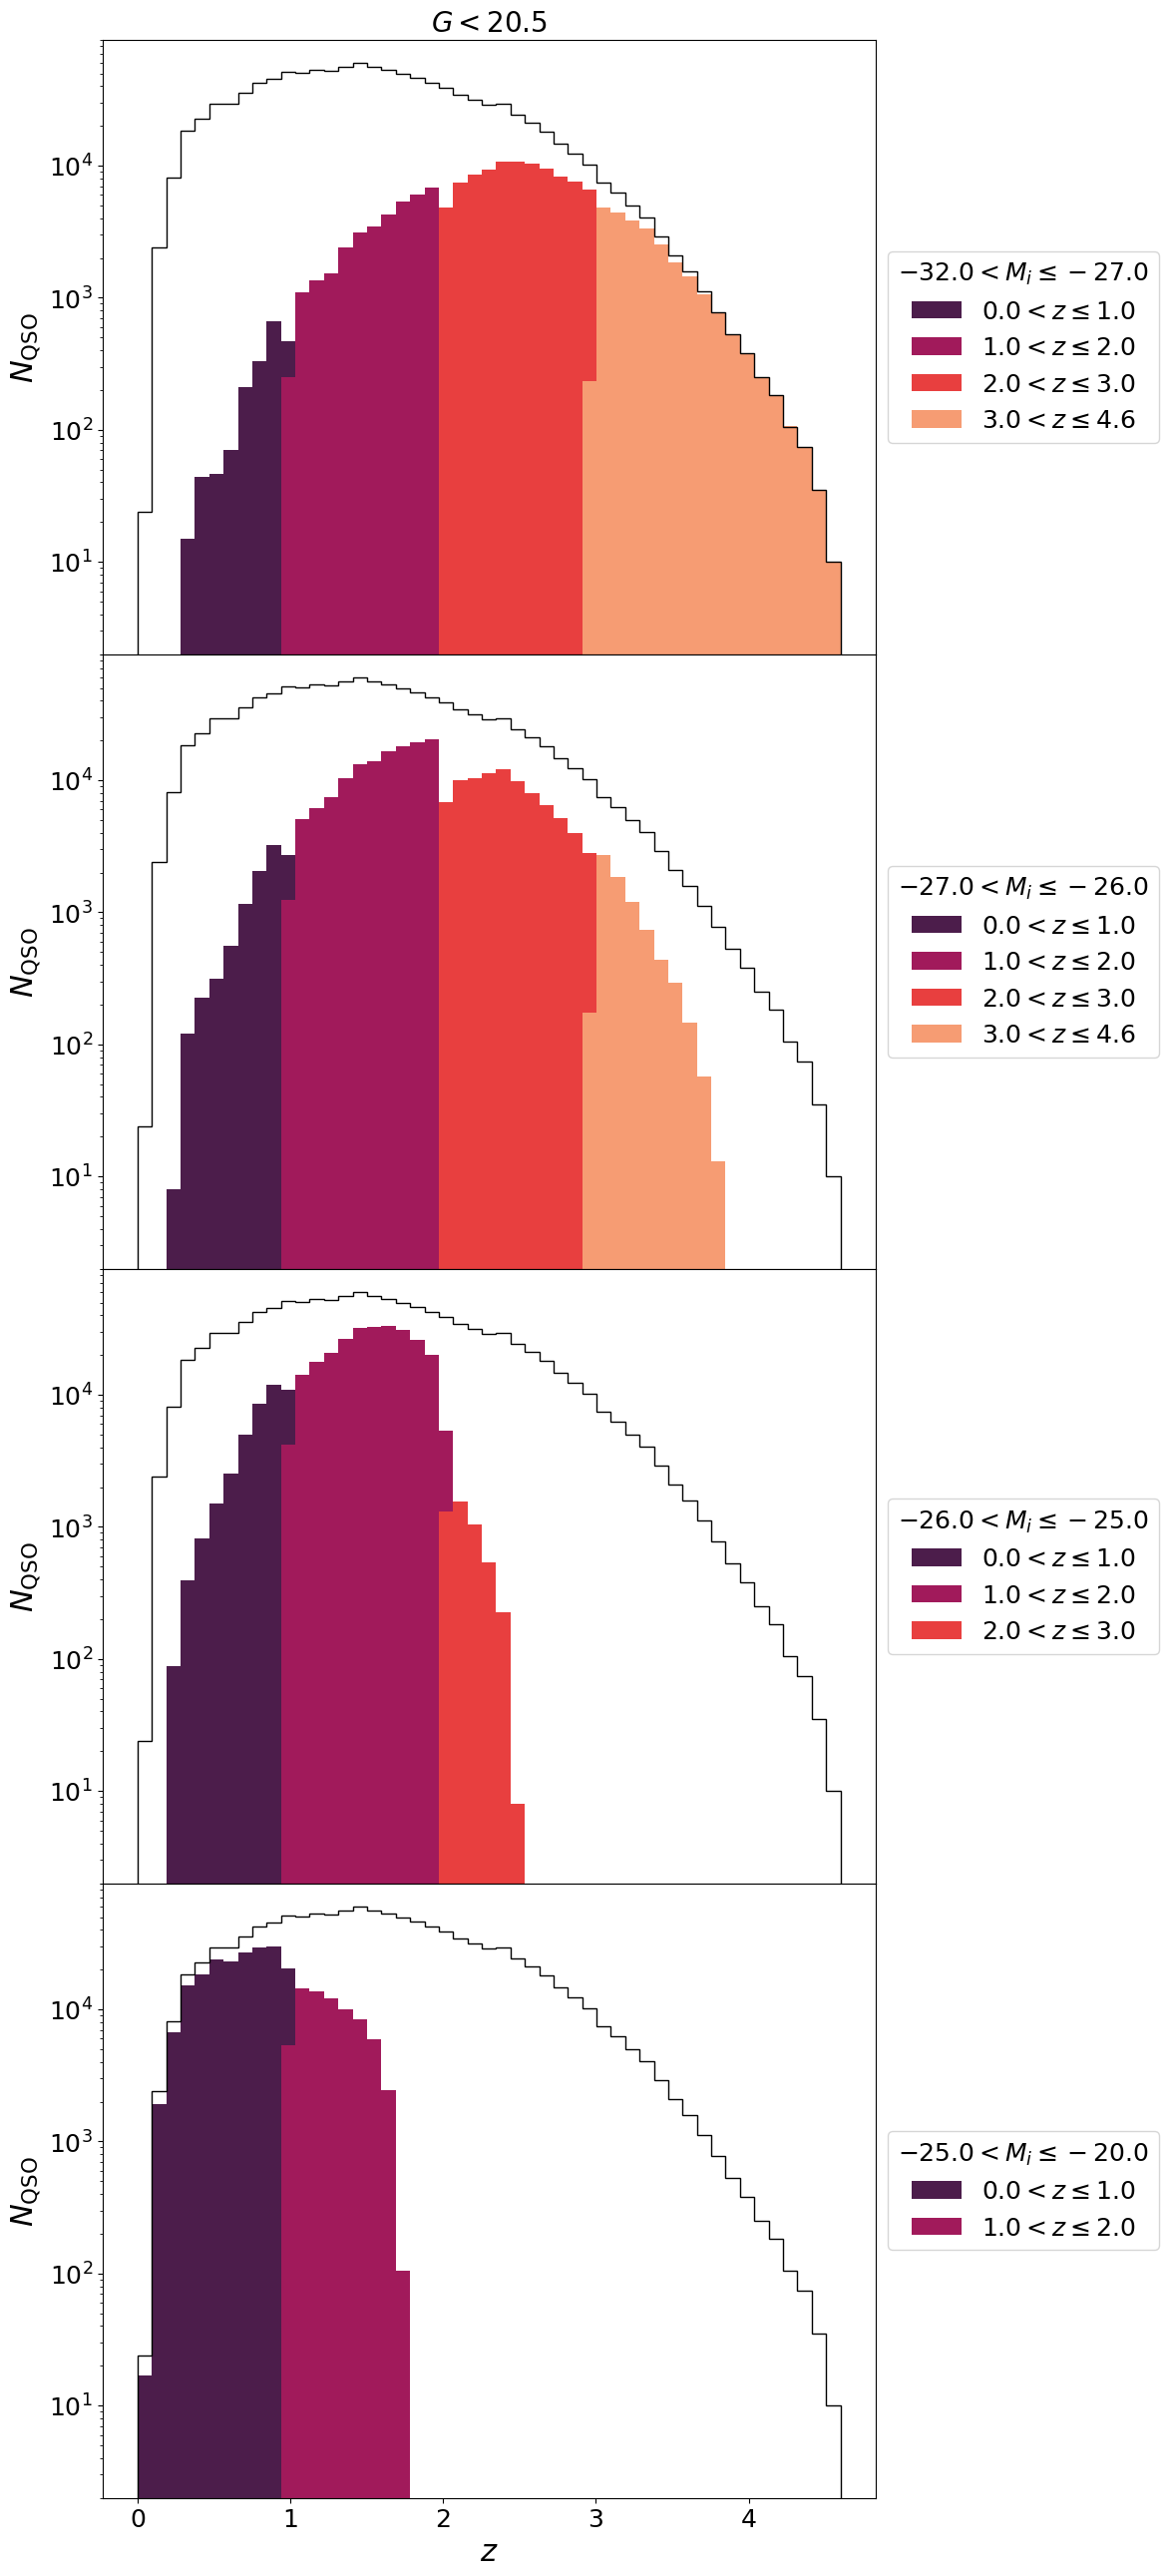

In [10]:
# plot data
bins = np.linspace(0, 4.6)

# plot!
fig = plt.figure(figsize = (10, 32))
gs = gridspec.GridSpec(4, 1, wspace = 0, hspace = 0)
loc = 'center left'
x = 1
N=[]

for j in L_array:

    ax1 = fig.add_subplot(gs[j])
    ax1.hist(tab_datahi[mask_datahi]['redshift_quaia'], bins=bins, histtype = 'step', color='black')

    N_z = []

    for k in z_array:

        try:
            tab_datahi_mask_zbin0, tab_randhi_mask_zbin0, key_zbin0, _, _, _, _= quaia.make_bins(G_hi, [k,j], True, ['z', 'L'], 
                                                                                                 bins = [z_bins, L_bins], tab_gcat_type = 'data',
                                                                                                 method = ['minmax', 'minmax'], fac_rand = 25,
                                                                                                 n_bins = [None, None], mask = mask)
            N_z.append(len(tab_datahi_mask_zbin0))
            ax1.hist(tab_datahi_mask_zbin0['redshift_quaia'], label = z_labels[k], bins = bins, color = cmap[k])
        except:
            print('G{}_zmin{}zmax{}_Lmin{}Lmax{}:                   no selection function'.format(G_hi, z_bins[j], z_bins[j+1], L_bins[k], 
                                                                                                  L_bins[k+1]))
    N.append(N_z)

    if j == 0:
        ax1.set_title('$G<{}$'.format(G_hi))
    if j == 3:
        ax1.set_xlabel('$z$')
    else:
        ax1.set_xticklabels([])
    ax1.set_yscale('log')
    ax1.legend(loc = loc, bbox_to_anchor = (x, 0.5), title = '${}<M_i\leq{}$'.format(L_bins[j], L_bins[j+1]), title_fontsize = 18)
    ax1.set_ylim(2, 9e4)
    ax1.set_ylabel('$N_\mathrm{QSO}$')

plt.show()

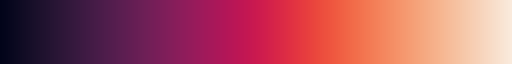

In [11]:
cmap_fduty = sns.color_palette("rocket", as_cmap = True)
cmap_fduty

<>:33: SyntaxWarning: invalid escape sequence '\m'
<>:41: SyntaxWarning: invalid escape sequence '\m'
<>:33: SyntaxWarning: invalid escape sequence '\m'
<>:41: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipykernel_154329/2533919628.py:33: SyntaxWarning: invalid escape sequence '\m'
  ax2_hi.set_ylabel('N$_\mathrm{QSO}$')
/tmp/ipykernel_154329/2533919628.py:41: SyntaxWarning: invalid escape sequence '\m'
  ax3_hi.set_xlabel('N$_\mathrm{QSO}$')


G20.5_zmin2.0zmax3.0_Lmin-25.0Lmax-20.0:                   no selection function
G20.5_zmin3.0zmax4.6_Lmin-26.0Lmax-25.0:                   no selection function
G20.5_zmin3.0zmax4.6_Lmin-25.0Lmax-20.0:                   no selection function


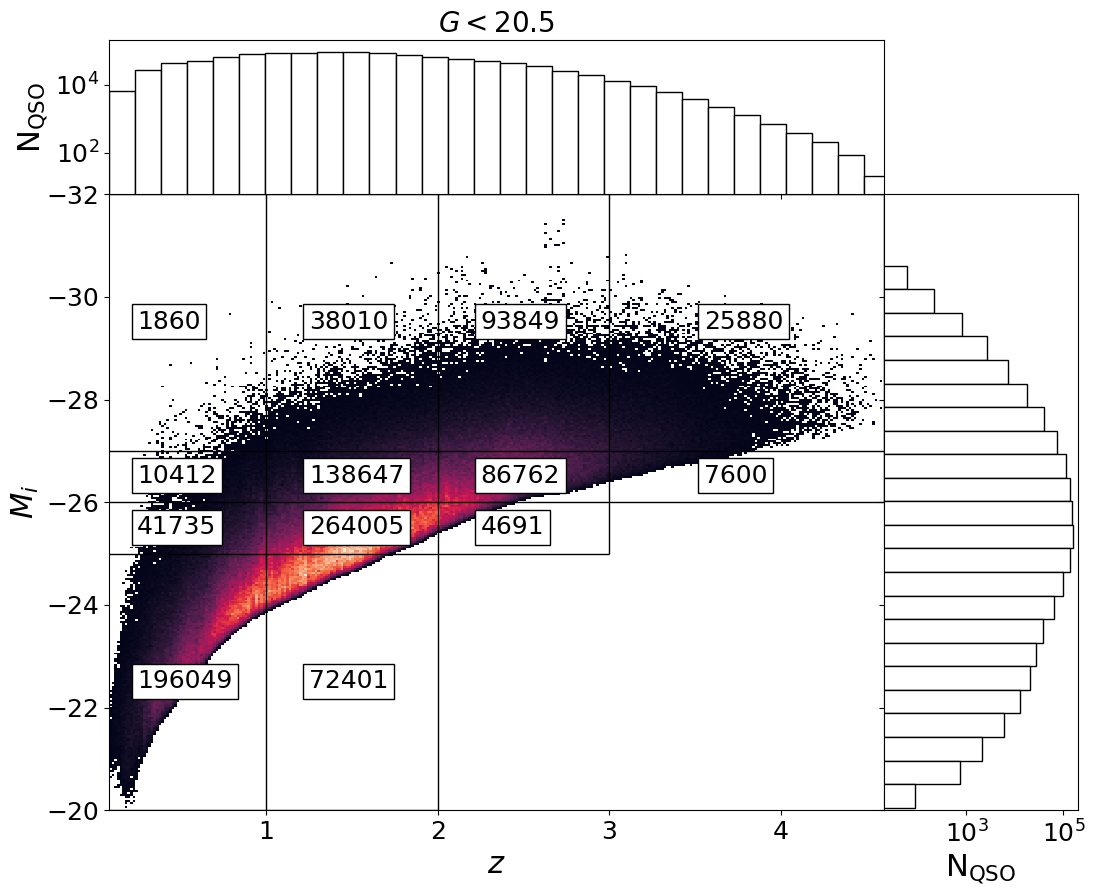

In [12]:
# plot!
fig = plt.figure(figsize = (12.5, 10))
gs = gridspec.GridSpec(2, 2, hspace = 0, height_ratios=[1,4], width_ratios=[4,1], wspace = 0)

ax1_hi = fig.add_subplot(gs[2])

quaia.absolute(tab_datahi, G_hi)
h1, xedges, yedges, image = ax1_hi.hist2d(tab_datahi['redshift_quaia'][mask_datahi], tab_datahi['M_i'][mask_datahi], cmap = cmap_fduty, bins = 300, 
                                       cmin = 1)

for L_bin, xmax in zip(L_bins, [z_bins[4], z_bins[4], z_bins[4], z_bins[3], z_bins[2]]):
    ax1_hi.hlines(L_bin, color = 'black', xmin = z_bins[0], xmax = xmax, linewidth = 1)
for z_bin, ymax in zip(z_bins, [L_bins[4], L_bins[4], L_bins[4], L_bins[3], L_bins[2]]):
    ax1_hi.vlines(z_bin, color = 'black', ymin = L_bins[0], ymax = ymax, linewidth = 1)
            
for i in z_array:
    for j in L_array:
        try:
            if N[j][i]>1000:
                ax1_hi.text(quaia.recenter(z_bins)[i]-0.25, quaia.recenter(L_bins)[j]+0.125, N[j][i], fontsize = 18, color = 'black', bbox=dict(facecolor='white'))
        except:
            print('G{}_zmin{}zmax{}_Lmin{}Lmax{}:                   no selection function'.format(G_hi, z_bins[i], z_bins[i+1], L_bins[j], 
                                                                                                      L_bins[j+1]))
ax1_hi.set_ylabel('$M_i$')
xlim = ax1_hi.get_xlim()
ax1_hi.set_xlabel('$z$')
ax1_hi.set_ylim(-20, -32)
ax1_hi.set_xlim(xlim[0], z_bins[-1])

ax2_hi = fig.add_subplot(gs[0])
ax2_hi.hist(tab_datahi['redshift_quaia'][mask_datahi], color = 'white', edgecolor = 'black', bins = 30)
ax2_hi.set_title('$G<{}$'.format(G_hi))
ax2_hi.set_ylabel('N$_\mathrm{QSO}$')
ax2_hi.set_yscale('log')
ax2_hi.set_xlim(xlim[0], z_bins[-1])
ax2_hi.set_ylim(6,2e5)
ax2_hi.set_xticklabels([])

ax3_hi = fig.add_subplot(gs[3])
ax3_hi.hist(tab_datahi['M_i'][mask_datahi], color = 'white', edgecolor = 'black', orientation = 'horizontal', bins = 25)
ax3_hi.set_xlabel('N$_\mathrm{QSO}$')
ax3_hi.set_xscale('log')
ax3_hi.set_yticklabels([])
ax3_hi.set_ylim(-20, -32)
ax3_hi.set_xlim(2e1,2e5)

plt.savefig('../figures/mag_mask_joint_G20.5.pdf', dpi = 300, bbox_inches='tight')
plt.show()

In [13]:
# Create the bins array
rmin = 0.1 # 0.1 # start higher
rmax = 180.0 # 20.0 #50.0
nbins = 20 #90 #20
sbins = np.logspace(np.log10(rmin), np.log10(rmax), nbins + 1) # Mpc/h https://github.com/manodeep/Corrfunc/issues/202
scale = 'log'

# # Create the bins array
# rmin = 0.1 # 0.1 # start higher
# rmax = 155.0 # 20.0 #50.0
# nbins = 20 #90 #20
# rbins = np.linspace(rmin, rmax, nbins + 1) # Mpc/h https://github.com/manodeep/Corrfunc/issues/202
# scale = 'lin'

In [14]:
# plot data
# bins = np.linspace(-32,-20)
cf = {G_lo: [], G_hi: []}

# # plot!
for i in range(len(G_array)):
    
    for j in z_array:
        
        cf_L = []
        for k in L_array:
        
            try:
                tab_datahi_mask_zbin0, tab_randhi_mask_zbin0, key_zbin0, _, _, _, _= quaia.make_bins(G_array[i], [j,k], True, ['z', 'L'], 
                                                                                                     bins = [z_bins, L_bins], tab_gcat_type = 'data',
                                                                                                     method = ['minmax', 'minmax'], fac_rand = 25,
                                                                                                     n_bins = [None, None], mask = mask)
                cf_L.append(quaia.xi_s(tab_datahi_mask_zbin0, tab_randhi_mask_zbin0, key_zbin0, nthreads = nthreads, rbins = sbins))
            except:
                print('G{}_zmin{}zmax{}_Lmin{}Lmax{}:                   no selection function'.format(G_array[i], z_bins[j], z_bins[j+1], L_bins[k], 
                                                                                                      L_bins[k+1]))
        cf[G_array[i]].append(cf_L)

NameError: name 'G_lo' is not defined

In [ ]:
# plot!
fig = plt.figure(figsize = (20, 32))
gs = gridspec.GridSpec(4, 2, wspace = 0, hspace = 0)

for i in range(len(G_array)):
    
    for j in z_array:
        
        ax1 = fig.add_subplot(gs[j*2+i])
        
        for k in L_array:
            
            try:
                ax1.plot(quaia.recenter(sbins), cf[G_array[i]][j][k], label = L_labels[k], linewidth = 2.5, marker = 'o', color = cmaps[i][k])
            except:
                print('G{}_zmin{}zmax{}_Lmin{}Lmax{}:                   no selection function'.format(G_array[i], z_bins[j], z_bins[j+1], L_bins[k], 
                                                                                                      L_bins[k+1]))
        
        if j == 0:
            ax1.set_title('$G<{}$'.format(G_array[i]))
        if scale == 'log':
            ax1.set_xscale('log')
        ax1.set_yscale('log')
        ax1.set_xlim(quaia.recenter(sbins)[0], quaia.recenter(sbins)[-1])
        ax1.set_ylim(1e-3, 4e1)
        ax1.legend(title = z_labels[j], title_fontsize = 18)
        if i==0:
            ax1.set_ylabel(r"$\xi(s)$")
        else:
            ax1.set_yticklabels([])
        if j == 3:
            ax1.set_xlabel(r'$s$ $[h^{-1}$ Mpc]') # projected
        else:
            ax1.set_xticklabels([])

plt.show()

In [ ]:
# plot!
# fig = plt.figure(figsize = (20, 32))
# gs = gridspec.GridSpec(4, 2, wspace = 0, hspace = 0)

i = 1
j = 1
    
    # for j in z_array:
        
        # ax1 = fig.add_subplot(gs[j*2+i])
        
for k in L_array:
    
    try:
        plt.plot(quaia.recenter(sbins), cf[G_array[i]][j][k], label = L_labels[k], linewidth = 2.5, marker = 'o', color = cmaps[i][k])
    except:
        print('G{}_zmin{}zmax{}_Lmin{}Lmax{}:                   no selection function'.format(G_array[i], z_bins[j], z_bins[j+1], L_bins[k], 
                                                                                              L_bins[k+1]))

plt.title('$G<{}$'.format(G_array[i]))
if scale == 'log':
    plt.xscale('log')
plt.yscale('log')
plt.xlim(quaia.recenter(sbins)[0], quaia.recenter(sbins)[-1])
plt.ylim(1e-3, 4e1)
plt.legend(title = z_labels[j], title_fontsize = 18, bbox_to_anchor = (x[i], 0.75))
plt.ylabel(r"$\xi(s)$")
plt.xlabel(r'$s$ $[h^{-1}$ Mpc]') # projected
plt.savefig('../figures/L_dependence.pdf', dpi = 300, bbox_inches='tight')
plt.show()

In [ ]:
# plot!
# fig = plt.figure(figsize = (20, 32))
# gs = gridspec.GridSpec(4, 2, wspace = 0, hspace = 0)
# plt.figure(figsize = (7, 5))
plt.figure(figsize = (8, 5))
i = 1
j = 1
    
    # for j in z_array:
        
        # ax1 = fig.add_subplot(gs[j*2+i])
        
for k in L_array:
    
    try:
        plt.plot(quaia.recenter(sbins), cf[G_array[i]][j][k], label = L_labels[k], linewidth = 2.5, marker = 'o', color = cmaps[i][k])
    except:
        print('G{}_zmin{}zmax{}_Lmin{}Lmax{}:                   no selection function'.format(G_array[i], z_bins[j], z_bins[j+1], L_bins[k], 
                                                                                              L_bins[k+1]))

plt.title('$G<{}$'.format(G_array[i]))
if scale == 'log':
    plt.xscale('log')
plt.yscale('log')
# plt.xlim(quaia.recenter(sbins)[0], quaia.recenter(sbins)[-1])
# plt.ylim(1e-3, 4e1)
plt.legend(title = z_labels[j], title_fontsize = 18, ncol = 2, bbox_to_anchor = (0.5, -0.25), loc='upper center')
plt.ylabel(r"$\xi(s)$")
plt.xlabel(r'$s$ $[h^{-1}$ Mpc]') # projected
# plt.savefig('../figures/L_dependence_vertical.pdf', dpi = 300, bbox_inches='tight')
plt.savefig('../figures/L_dependence_vertical', dpi = 300, bbox_inches='tight')
plt.show()

In [ ]:
# plot!
# plt.figure(figsize = (8, 5))
i = 1
j = 1
        
for k in L_array:
    
    try:
        plt.plot(quaia.recenter(sbins), cf[G_array[i]][j][k], label = L_labels[k], linewidth = 2.5, marker = 'o', color = cmaps[i][k])
    except:
        print('G{}_zmin{}zmax{}_Lmin{}Lmax{}:                   no selection function'.format(G_array[i], z_bins[j], z_bins[j+1], L_bins[k], 
                                                                                              L_bins[k+1]))

plt.title('$G<{}$'.format(G_array[i]))
if scale == 'log':
    plt.xscale('log')
plt.yscale('log')
plt.legend(title = z_labels[j], title_fontsize = 18, bbox_to_anchor = (0.5, -0.25), loc='upper center')
plt.ylabel(r"$\xi(s)$")
plt.xlabel(r'$s$ $[h^{-1}$ Mpc]') # projected
# plt.savefig('../figures/L_dependence_vertical', dpi = 300, bbox_inches='tight')
plt.show()

In [ ]:
# plot!
fig = plt.figure(figsize = (20, 32))
gs = gridspec.GridSpec(4, 2, wspace = 0, hspace = 0)

for i in range(len(G_array)):
    
    for j in L_array:
        
        ax1 = fig.add_subplot(gs[j*2+i])
        
        for k in z_array:
            
            try:
                ax1.plot(quaia.recenter(sbins), cf[G_array[i]][k][j], label = z_labels[k], linewidth = 2.5, marker = 'o', color = cmaps[i][::-1][k])
            except:
                print('G{}_zmin{}zmax{}_Lmin{}Lmax{}:                   no selection function'.format(G_array[i], z_bins[j], z_bins[j+1], L_bins[k], 
                                                                                                      L_bins[k+1]))
        
        if j == 0:
            ax1.set_title('$G<{}$'.format(G_array[i]))
        if scale == 'log':
            ax1.set_xscale('log')
        ax1.set_yscale('log')
        ax1.set_xlim(quaia.recenter(sbins)[0], quaia.recenter(sbins)[-1])
        ax1.set_ylim(1e-3, 4e1)
        ax1.legend(title = L_labels[j], title_fontsize = 18)
        if i==0:
            ax1.set_ylabel(r"$\xi(s)$")
        else:
            ax1.set_yticklabels([])
        if j == 3:
            ax1.set_xlabel(r'$s$ $[h^{-1}$ Mpc]') # projected
        else:
            ax1.set_xticklabels([])

plt.show()

In [ ]:
# plot!
fig = plt.figure(figsize = (40, 32))
gs = gridspec.GridSpec(4, 4, wspace = 0, hspace = 0)
        
for j in z_array:

    for k in L_array:
        
        ax1 = fig.add_subplot(gs[j*4+k])
            
        for i in range(len(G_array)):
        
            try:
                ax1.plot(quaia.recenter(sbins), cf[G_array[i]][j][k], label = '$G<{}$'.format(G_array[i]), linewidth = 2.5, marker = 'o', 
                 color = cmaps[i][k])
            except:
                print('G{}_zmin{}zmax{}_Lmin{}Lmax{}:                   no selection function'.format(G_array[i], z_bins[j], z_bins[j+1], L_bins[k], 
                                                                                                      L_bins[k+1]))
        
        if j == 0:
            ax1.set_title(L_labels[k])
        if scale == 'log':
            ax1.set_xscale('log')
        ax1.set_yscale('log')
        ax1.set_xlim(quaia.recenter(sbins)[0], quaia.recenter(sbins)[-1])
        ax1.set_ylim(1e-4, 5e2)
        ax1.legend(title = z_labels[j], title_fontsize = 18)
        if j > 2:
            ax1.set_xlabel(r'$s$ $[h^{-1}$ Mpc]') # projected
        else: 
            ax1.set_xticklabels([])
        if k==0:
            ax1.set_ylabel(r"$\xi(s)$")
        else:
            ax1.set_yticklabels([])

plt.show()

In [ ]:
# plot!
fig = plt.figure(figsize = (40, 32))
gs = gridspec.GridSpec(4, 4, wspace = 0, hspace = 0)
        
for j in L_array:

    for k in z_array:
        
        ax1 = fig.add_subplot(gs[j*4+k])
            
        for i in range(len(G_array)):
        
            try:
                ax1.plot(quaia.recenter(sbins), cf[G_array[i]][k][j], label = '$G<{}$'.format(G_array[i]), linewidth = 2.5, marker = 'o', 
                 color = cmaps[i][::-1][k])
            except:
                print('G{}_zmin{}zmax{}_Lmin{}Lmax{}:                   no selection function'.format(G_array[i], z_bins[j], z_bins[j+1], L_bins[k], 
                                                                                                      L_bins[k+1]))
        
        if j == 0:
            ax1.set_title(z_labels[k])
        if scale == 'log':
            ax1.set_xscale('log')
        ax1.set_yscale('log')
        ax1.set_xlim(quaia.recenter(sbins)[0], quaia.recenter(sbins)[-1])
        ax1.set_ylim(1e-4, 5e2)
        ax1.legend(title = L_labels[j], title_fontsize = 18)
        if j > 2:
            ax1.set_xlabel(r'$s$ $[h^{-1}$ Mpc]') # projected
        else: 
            ax1.set_xticklabels([])
        if k==0:
            ax1.set_ylabel(r"$\xi(s)$")
        else:
            ax1.set_yticklabels([])

plt.show()

In [ ]:
# Create the bins array
rmin = 0.15 # 0.5 # 0.1 # start higher
rmax = 240 # 120 #85 # 60.0 # 20.0 
nbins = 20 
rbins = np.logspace(np.log10(rmin), np.log10(rmax), nbins + 1) # Mpc/h https://github.com/manodeep/Corrfunc/issues/202
scale = 'log'

# rmin = 0.15 # 0.5 # 0.1 # start higher
# rmax = 210 # 120 #85 # 60.0 # 20.0 
# nbins = 20 
# rbins = np.linspace(rmin, rmax, nbins + 1) # Mpc/h https://github.com/manodeep/Corrfunc/issues/202
# scale = 'lin'

In [ ]:
pimax = 80 # 40 # 5000.0 # 40.0

In [ ]:
# plot data
wp, rpavg = {20.0: [], 20.5: []}, {20.0: [], 20.5: []}
for G in G_array:

    for j in z_array:
        
        wp_L = []
        rpavg_L = []
        for k in L_array:
            
            try:
                tab_datahi_mask_zbin0, tab_randhi_mask_zbin0, key_zbin0, _, _, _, _= quaia.make_bins(G, [j,k], True, ['z', 'L'], 
                                                                                                     bins = [z_bins, L_bins], tab_gcat_type = 'data',
                                                                                                     method = ['minmax', 'minmax'], fac_rand = 25,
                                                                                                     n_bins = [None, None], mask = mask)
                
                wp_datahi_zbin0, rpavg_datahi_zbin0 = quaia.wp_rp(tab_datahi_mask_zbin0, tab_randhi_mask_zbin0, key_zbin0, nthreads = nthreads, 
                                                                  rbins = rbins, nbins = nbins, pimax = pimax)
                wp_L.append(wp_datahi_zbin0)
                rpavg_L.append(rpavg_datahi_zbin0)
                
            except:
                print('G{}_zmin{}zmax{}_Lmin{}Lmax{}:                   no selection function'.format(G_array[i], z_bins[j], z_bins[j+1], L_bins[k], 
                                                                                                      L_bins[k+1]))
        wp[G].append(wp_L)
        rpavg[G].append(rpavg_L)       

In [ ]:
# plot!
fig = plt.figure(figsize = (20, 32))
gs = gridspec.GridSpec(4, 2, wspace = 0, hspace = 0)

for i in range(len(G_array)):
    
    for j in z_array:
        
        ax1 = fig.add_subplot(gs[j*2+i])
        
        for k in L_array:
            
            try:
        
                ax1.plot(rpavg[G_array[i]][j][k], wp[G_array[i]][j][k], label = L_labels[k], linewidth = 2.5, marker = 'o', color = cmaps[i][k])
            except:
                print('G{}_zmin{}zmax{}_Lmin{}Lmax{}:                   no selection function'.format(G_array[i], z_bins[j], z_bins[j+1], L_bins[k], 
                                                                                                      L_bins[k+1]))
        
        if j == 0:
            ax1.set_title('$G<{}$'.format(G_array[i]))
        if scale == 'log':
            ax1.set_xscale('log')
        ax1.set_yscale('log')
        ax1.set_xlim(quaia.recenter(rbins)[0], quaia.recenter(rbins)[-1])
        ax1.set_ylim(2e-2, 3e3)
        ax1.legend(title = z_labels[j], title_fontsize = 18)

        if i==0:
            ax1.set_ylabel(r"$w_p(r_p)[h^{-1}$ Mpc]")
        else:
            ax1.set_yticklabels([])
        if j > 2:
            ax1.set_xlabel(r'$r_p$ $[h^{-1}$ Mpc]') # projected
        else:
            ax1.set_xticklabels([])

plt.show()

In [ ]:
# plot!
fig = plt.figure(figsize = (20, 32))
gs = gridspec.GridSpec(4, 2, wspace = 0, hspace = 0)

for i in range(len(G_array)):
    
    for j in L_array:
        
        ax1 = fig.add_subplot(gs[j*2+i])
        
        for k in z_array:
            
            try:
        
                ax1.plot(rpavg[G_array[i]][k][j], wp[G_array[i]][k][j], label = z_labels[k], linewidth = 2.5, marker = 'o', color = cmaps[i][::-1][k])
            except:
                print('G{}_zmin{}zmax{}_Lmin{}Lmax{}:                   no selection function'.format(G_array[i], z_bins[j], z_bins[j+1], L_bins[k], 
                                                                                                      L_bins[k+1]))
        
        if j == 0:
            ax1.set_title('$G<{}$'.format(G_array[i]))
        if scale == 'log':
            ax1.set_xscale('log')
        ax1.set_yscale('log')
        ax1.set_xlim(quaia.recenter(rbins)[0], quaia.recenter(rbins)[-1])
        ax1.set_ylim(2e-2, 3e3)
        ax1.legend(title = L_labels[j], title_fontsize = 18)

        if i==0:
            ax1.set_ylabel(r"$w_p(r_p)[h^{-1}$ Mpc]")
        else:
            ax1.set_yticklabels([])
        if j > 2:
            ax1.set_xlabel(r'$r_p$ $[h^{-1}$ Mpc]') # projected
        else:
            ax1.set_xticklabels([])

plt.show()

In [ ]:
# plot!
fig = plt.figure(figsize = (40, 32))
gs = gridspec.GridSpec(4, 4, wspace = 0, hspace = 0)
        
for j in z_array:

    for k in L_array:
        
        ax1 = fig.add_subplot(gs[j*4+k])
            
        for i in range(len(G_array)):
        
            try:
                ax1.plot(rpavg[G_array[i]][j][k], wp[G_array[i]][j][k], label = '$G<{}$'.format(G_array[i]), linewidth = 2.5, marker = 'o', 
                 color = cmaps[i][k])
            except:
                print('G{}_zmin{}zmax{}_Lmin{}Lmax{}:                   no selection function'.format(G_array[i], z_bins[j], z_bins[j+1], L_bins[k], 
                                                                                                      L_bins[k+1]))
        
        if j == 0:
            ax1.set_title(L_labels[k])
        if scale == 'log':
            ax1.set_xscale('log')
        ax1.set_yscale('log')
        ax1.set_xlim(quaia.recenter(rbins)[0], quaia.recenter(rbins)[-1])
        ax1.set_ylim(2e-2, 3e3)
        ax1.legend(title = z_labels[j], title_fontsize = 18)
        if j > 2:
            ax1.set_xlabel(r'$r_p$ $[h^{-1}$ Mpc]') # projected
        else: 
            ax1.set_xticklabels([])
        if k==0:
            ax1.set_ylabel(r"$w_p(r_p)[h^{-1}$ Mpc]")
        else:
            ax1.set_yticklabels([])

plt.show()

In [ ]:
# plot!
fig = plt.figure(figsize = (40, 32))
gs = gridspec.GridSpec(4, 4, wspace = 0, hspace = 0)
        
for k in z_array:

    for j in L_array:
        
        ax1 = fig.add_subplot(gs[j*4+k])
            
        for i in range(len(G_array)):
        
            try:
                ax1.plot(rpavg[G_array[i]][k][j], wp[G_array[i]][k][j], label = '$G<{}$'.format(G_array[i]), linewidth = 2.5, marker = 'o', 
                 color = cmaps[i][::-1][k])
            except:
                print('G{}_zmin{}zmax{}_Lmin{}Lmax{}:                   no selection function'.format(G_array[i], z_bins[j], z_bins[j+1], L_bins[k], 
                                                                                                      L_bins[k+1]))
        
        if j == 0:
            ax1.set_title(z_labels[k])
        if scale == 'log':
            ax1.set_xscale('log')
        ax1.set_yscale('log')
        ax1.set_xlim(quaia.recenter(rbins)[0], quaia.recenter(rbins)[-1])
        ax1.set_ylim(2e-2, 3e3)
        ax1.legend(title = L_labels[j], title_fontsize = 18)
        if j > 2:
            ax1.set_xlabel(r'$r_p$ $[h^{-1}$ Mpc]') # projected
        else: 
            ax1.set_xticklabels([])
        if k==0:
            ax1.set_ylabel(r"$w_p(r_p)[h^{-1}$ Mpc]")
        else:
            ax1.set_yticklabels([])

plt.show()

In [ ]:
# plot!
fig = plt.figure(figsize = (20, 32))
gs = gridspec.GridSpec(4, 2, wspace = 0, hspace = 0)

for i in range(len(G_array)):
    
    for j in z_array:
        
        ax1 = fig.add_subplot(gs[j*2+i])
        
        for k in L_array:
            
            try:
        
                ax1.plot(rpavg[G_array[i]][j][k], wp[G_array[i]][j][k]/rpavg[G_array[i]][j][k], label = L_labels[k], linewidth = 2.5, marker = 'o', color = cmaps[i][k])
            except:
                print('G{}_zmin{}zmax{}_Lmin{}Lmax{}:                   no selection function'.format(G_array[i], z_bins[j], z_bins[j+1], L_bins[k], 
                                                                                                      L_bins[k+1]))
        
        if j == 0:
            ax1.set_title('$G<{}$'.format(G_array[i]))
        if scale == 'log':
            ax1.set_xscale('log')
        ax1.set_yscale('log')
        ax1.set_xlim(quaia.recenter(rbins)[0], quaia.recenter(rbins)[-1])
        ax1.set_ylim(1e-4, 2e4)
        ax1.legend(title = z_labels[j], title_fontsize = 18)

        if i==0:
            ax1.set_ylabel(r"$w_p(r_p)/r_p$")
        else:
            ax1.set_yticklabels([])
        if j > 2:
            ax1.set_xlabel(r'$r_p$ $[h^{-1}$ Mpc]') # projected
        else:
            ax1.set_xticklabels([])

plt.show()

In [ ]:
# plot!
fig = plt.figure(figsize = (20, 32))
gs = gridspec.GridSpec(4, 2, wspace = 0, hspace = 0)

for i in range(len(G_array)):
    
    for j in L_array:
        
        ax1 = fig.add_subplot(gs[j*2+i])
        
        for k in z_array:
            
            try:
        
                ax1.plot(rpavg[G_array[i]][k][j], wp[G_array[i]][k][j]/rpavg[G_array[i]][k][j], label = z_labels[k], linewidth = 2.5, marker = 'o', 
                         color = cmaps[i][::-1][k])
            except:
                print('G{}_zmin{}zmax{}_Lmin{}Lmax{}:                   no selection function'.format(G_array[i], z_bins[j], z_bins[j+1], L_bins[k], 
                                                                                                      L_bins[k+1]))
        
        if j == 0:
            ax1.set_title('$G<{}$'.format(G_array[i]))
        if scale == 'log':
            ax1.set_xscale('log')
        ax1.set_yscale('log')
        ax1.set_xlim(quaia.recenter(rbins)[0], quaia.recenter(rbins)[-1])
        ax1.set_ylim(1e-4, 2e4)
        ax1.legend(title = L_labels[j], title_fontsize = 18)

        if i==0:
            ax1.set_ylabel(r"$w_p(r_p)/r_p$")
        else:
            ax1.set_yticklabels([])
        if j > 2:
            ax1.set_xlabel(r'$r_p$ $[h^{-1}$ Mpc]') # projected
        else:
            ax1.set_xticklabels([])

plt.show()

In [ ]:
# plot!
fig = plt.figure(figsize = (40, 32))
gs = gridspec.GridSpec(4, 4, wspace = 0, hspace = 0)
        
for j in z_array:

    for k in L_array:
        
        ax1 = fig.add_subplot(gs[j*4+k])
            
        for i in range(len(G_array)):
        
            try:
                ax1.plot(rpavg[G_array[i]][j][k], wp[G_array[i]][j][k]/rpavg[G_array[i]][j][k], label = '$G<{}$'.format(G_array[i]), linewidth = 2.5, 
                         marker = 'o', 
                 color = cmaps[i][k])
            except:
                print('G{}_zmin{}zmax{}_Lmin{}Lmax{}:                   no selection function'.format(G_array[i], z_bins[j], z_bins[j+1], L_bins[k], 
                                                                                                      L_bins[k+1]))
        
        if j == 0:
            ax1.set_title(L_labels[k])
        if scale == 'log':
            ax1.set_xscale('log')
        ax1.set_yscale('log')
        ax1.set_xlim(quaia.recenter(rbins)[0], quaia.recenter(rbins)[-1])
        ax1.set_ylim(1e-4, 2e4)
        ax1.legend(title = z_labels[j], title_fontsize = 18)
        if j > 2:
            ax1.set_xlabel(r'$r_p$ $[h^{-1}$ Mpc]') # projected
        else: 
            ax1.set_xticklabels([])
        if k==0:
            ax1.set_ylabel(r"$w_p(r_p)/r_p$")
        else:
            ax1.set_yticklabels([])

plt.show()

In [ ]:
# plot!
fig = plt.figure(figsize = (40, 32))
gs = gridspec.GridSpec(4, 4, wspace = 0, hspace = 0)
        
for k in z_array:

    for j in L_array:
        
        ax1 = fig.add_subplot(gs[j*4+k])
            
        for i in range(len(G_array)):
        
            try:
                ax1.plot(rpavg[G_array[i]][k][j], wp[G_array[i]][k][j]/rpavg[G_array[i]][k][j], label = '$G<{}$'.format(G_array[i]), linewidth = 2.5, 
                         marker = 'o', 
                 color = cmaps[i][::-1][k])
            except:
                print('G{}_zmin{}zmax{}_Lmin{}Lmax{}:                   no selection function'.format(G_array[i], z_bins[j], z_bins[j+1], L_bins[k], 
                                                                                                      L_bins[k+1]))
        
        if j == 0:
            ax1.set_title(z_labels[k])
        if scale == 'log':
            ax1.set_xscale('log')
        ax1.set_yscale('log')
        ax1.set_xlim(quaia.recenter(rbins)[0], quaia.recenter(rbins)[-1])
        ax1.set_ylim(1e-4, 2e4)
        ax1.legend(title = L_labels[j], title_fontsize = 18)
        if j > 2:
            ax1.set_xlabel(r'$r_p$ $[h^{-1}$ Mpc]') # projected
        else: 
            ax1.set_xticklabels([])
        if k==0:
            ax1.set_ylabel(r"$w_p(r_p)/r_p$")
        else:
            ax1.set_yticklabels([])

plt.show()

In [ ]:
# plot!
fig = plt.figure(figsize = (20, 32))
gs = gridspec.GridSpec(4, 2, wspace = 0, hspace = 0)

for i in range(len(G_array)):
    
    for j in z_array:
        
        ax1 = fig.add_subplot(gs[j*2+i])
        
        for k in L_array:
            
            try:
        
                ax1.plot(quaia.recenter(sbins), cf[G_array[i]][j][k], label = L_labels[k], linewidth = 2.5, marker = 'o', 
                         color = cmaps[i][k])
                ax1.plot(rpavg[G_array[i]][j][k], wp[G_array[i]][j][k]/rpavg[G_array[i]][j][k], linewidth = 2.5, marker = 'o', 
                         color = cmaps[i][k], linestyle = '--')
            except:
                print('G{}_zmin{}zmax{}_Lmin{}Lmax{}:                   no selection function'.format(G_array[i], z_bins[j], z_bins[j+1], L_bins[k], 
                                                                                                      L_bins[k+1]))
        
        if j == 0:
            ax1.set_title('$G<{}$'.format(G_array[i]))
        if scale == 'log':
            ax1.set_xscale('log')
        ax1.set_yscale('log')
        ax1.set_xlim(quaia.recenter(rbins)[0], quaia.recenter(rbins)[-1])
        ax1.set_ylim(1e-4, 2e4)
        ax1.legend(title = z_labels[j], title_fontsize = 18)

        if i==0:
            ax1.set_ylabel(r"$\xi(s), w_p(r_p)/r_p$")
        else:
            ax1.set_yticklabels([])
        if j > 2:
            ax1.set_xlabel(r'$s, r_p$ $[h^{-1}$ Mpc]') # projected
        else:
            ax1.set_xticklabels([])

plt.show()

In [ ]:
# plot!
fig = plt.figure(figsize = (20, 32))
gs = gridspec.GridSpec(4, 2, wspace = 0, hspace = 0)

for i in range(len(G_array)):
    
    for j in L_array:
        
        ax1 = fig.add_subplot(gs[j*2+i])
        
        for k in z_array:
            
            try:
        
                ax1.plot(quaia.recenter(sbins), cf[G_array[i]][k][j], label = z_labels[k], linewidth = 2.5, marker = 'o', 
                         color = cmaps[i][::-1][k])
                ax1.plot(rpavg[G_array[i]][k][j], wp[G_array[i]][k][j]/rpavg[G_array[i]][k][j], linewidth = 2.5, marker = 'o', 
                         color = cmaps[i][::-1][k], linestyle = '--')
            except:
                print('G{}_zmin{}zmax{}_Lmin{}Lmax{}:                   no selection function'.format(G_array[i], z_bins[j], z_bins[j+1], L_bins[k], 
                                                                                                      L_bins[k+1]))
        
        if j == 0:
            ax1.set_title('$G<{}$'.format(G_array[i]))
        if scale == 'log':
            ax1.set_xscale('log')
        ax1.set_yscale('log')
        ax1.set_xlim(quaia.recenter(rbins)[0], quaia.recenter(rbins)[-1])
        ax1.set_ylim(1e-4, 2e4)
        ax1.legend(title = L_labels[j], title_fontsize = 18)

        if i==0:
            ax1.set_ylabel(r"$\xi(s), w_p(r_p)/r_p$")
        else:
            ax1.set_yticklabels([])
        if j > 2:
            ax1.set_xlabel(r'$s, r_p$ $[h^{-1}$ Mpc]') # projected
        else:
            ax1.set_xticklabels([])

plt.show()

In [ ]:
# plot!
fig = plt.figure(figsize = (40, 32))
gs = gridspec.GridSpec(4, 4, wspace = 0, hspace = 0)
        
for j in z_array:

    for k in L_array:
        
        ax1 = fig.add_subplot(gs[j*4+k])
            
        for i in range(len(G_array)):
        
            try:
                ax1.plot(quaia.recenter(sbins), cf[G_array[i]][j][k], label = '$G<{}, \\xi(s)$'.format(G_array[i]), 
                         linewidth = 2.5, marker = 'o', color = cmaps[i][k])
                ax1.plot(rpavg[G_array[i]][j][k], wp[G_array[i]][j][k]/rpavg[G_array[i]][j][k], label = '$G<{}, w_p(r_p)$'.format(G_array[i]), 
                         linewidth = 2.5, marker = 'o', color = cmaps[i][k], linestyle = '--')
            except:
                print('G{}_zmin{}zmax{}_Lmin{}Lmax{}:                   no selection function'.format(G_array[i], z_bins[j], z_bins[j+1], L_bins[k], 
                                                                                                      L_bins[k+1]))
        
        if j == 0:
            ax1.set_title(L_labels[k])
        if scale == 'log':
            ax1.set_xscale('log')
        ax1.set_yscale('log')
        ax1.set_xlim(quaia.recenter(rbins)[0], quaia.recenter(rbins)[-1])
        ax1.set_ylim(1e-4, 2e4)
        ax1.legend(title = z_labels[j], title_fontsize = 18, ncol = 2)
        if j > 2:
            ax1.set_xlabel(r'$r_p$ $[h^{-1}$ Mpc]') # projected
        else: 
            ax1.set_xticklabels([])
        if k==0:
            ax1.set_ylabel(r"$w_p(r_p)/r_p$")
        else:
            ax1.set_yticklabels([])

plt.show()

In [ ]:
# plot!
fig = plt.figure(figsize = (40, 32))
gs = gridspec.GridSpec(4, 4, wspace = 0, hspace = 0)
        
for k in z_array:

    for j in L_array:
        
        ax1 = fig.add_subplot(gs[j*4+k])
            
        for i in range(len(G_array)):
        
            try:
                ax1.plot(quaia.recenter(sbins), cf[G_array[i]][k][j], label = '$G<{}, \\xi(s)$'.format(G_array[i]), 
                         linewidth = 2.5, marker = 'o', color = cmaps[i][::-1][k])
                ax1.plot(rpavg[G_array[i]][k][j], wp[G_array[i]][k][j]/rpavg[G_array[i]][k][j], label = '$G<{}, w_p(r_p)$'.format(G_array[i]), 
                         linewidth = 2.5, marker = 'o', color = cmaps[i][::-1][k], linestyle = '--')
            except:
                print('G{}_zmin{}zmax{}_Lmin{}Lmax{}:                   no selection function'.format(G_array[i], z_bins[j], z_bins[j+1], L_bins[k], 
                                                                                                      L_bins[k+1]))
        
        if j == 0:
            ax1.set_title(z_labels[k])
        if scale == 'log':
            ax1.set_xscale('log')
        ax1.set_yscale('log')
        ax1.set_xlim(quaia.recenter(rbins)[0], quaia.recenter(rbins)[-1])
        ax1.set_ylim(1e-4, 2e4)
        ax1.legend(title = L_labels[j], title_fontsize = 18, ncol = 2)
        if j > 2:
            ax1.set_xlabel(r'$r_p$ $[h^{-1}$ Mpc]') # projected
        else: 
            ax1.set_xticklabels([])
        if k==0:
            ax1.set_ylabel(r"$w_p(r_p)/r_p$")
        else:
            ax1.set_yticklabels([])

plt.show()

In [ ]:
# Create the bins array
# thetabins = np.logspace(np.log10(0.1), np.log10(10), 15) 
thetabins = np.logspace(np.log10(0.1), np.log10(35), 15) #(np.log10(0.15), np.log10(35), 15)

In [ ]:
# plot data
wtheta = {G_lo: [], G_hi: []}
for G in G_array:

    for j in z_array:
        
        wtheta_L = []
        for k in L_array:
            
            try:
                tab_datahi_mask_zbin0, tab_randhi_mask_zbin0, key_zbin0, _, _, _, _= quaia.make_bins(G, [j,k], True, ['z', 'L'], 
                                                                                                     bins = [z_bins, L_bins], tab_gcat_type = 'data',
                                                                                                     method = ['minmax', 'minmax'], fac_rand = 25,
                                                                                                     n_bins = [None, None], z = False)
                
                wtheta_L.append(quaia.w_theta(tab_datahi_mask_zbin0, tab_randhi_mask_zbin0, nthreads = nthreads, thetabins = thetabins))
                
            except:
                print('G{}_zmin{}zmax{}_Lmin{}Lmax{}:                   no selection function'.format(G_array[i], z_bins[j], z_bins[j+1], L_bins[k], 
                                                                                                      L_bins[k+1]))
        wtheta[G].append(wtheta_L)    

In [ ]:
# plot!
fig = plt.figure(figsize = (20, 32))
gs = gridspec.GridSpec(4, 2, wspace = 0, hspace = 0)

for i in range(len(G_array)):
    
    for j in z_array:
        
        ax1 = fig.add_subplot(gs[j*2+i])
        
        for k in L_array:
            
            try:
        
                ax1.plot(quaia.recenter(thetabins), wtheta[G_array[i]][j][k], label = L_labels[k], linewidth = 2.5, marker = 'o', color = cmaps[i][k])
            except:
                print('G{}_zmin{}zmax{}_Lmin{}Lmax{}:                   no selection function'.format(G_array[i], z_bins[j], z_bins[j+1], L_bins[k], 
                                                                                                      L_bins[k+1]))
        
        if j == 0:
            ax1.set_title('$G<{}$'.format(G_array[i]))
        ax1.set_xscale('log')
        ax1.set_yscale('log')
        ax1.set_xlim(quaia.recenter(thetabins)[0], quaia.recenter(thetabins)[-1])
        ax1.set_ylim(1e-6, 9e1)
        ax1.legend(title = z_labels[j], title_fontsize = 18)

        if i==0:
            ax1.set_ylabel(r"$w(\theta)$")
        else:
            ax1.set_yticklabels([])
        if j > 2:
            ax1.set_xlabel(r'$\theta[^{\circ}]$')
        else:
            ax1.set_xticklabels([])

plt.show()

In [ ]:
# plot!
fig = plt.figure(figsize = (20, 32))
gs = gridspec.GridSpec(4, 2, wspace = 0, hspace = 0)

for i in range(len(G_array)):
    
    for j in L_array:
        
        ax1 = fig.add_subplot(gs[j*2+i])
        
        for k in z_array:
            
            try:
        
                ax1.plot(quaia.recenter(thetabins), wtheta[G_array[i]][k][j], label = z_labels[k], linewidth = 2.5, marker = 'o', 
                         color = cmaps[i][::-1][k])
            except:
                print('G{}_zmin{}zmax{}_Lmin{}Lmax{}:                   no selection function'.format(G_array[i], z_bins[j], z_bins[j+1], L_bins[k], 
                                                                                                      L_bins[k+1]))
        
        if j == 0:
            ax1.set_title('$G<{}$'.format(G_array[i]))
        ax1.set_xscale('log')
        ax1.set_yscale('log')
        ax1.set_xlim(quaia.recenter(thetabins)[0], quaia.recenter(thetabins)[-1])
        ax1.set_ylim(1e-6, 9e1)
        ax1.legend(title = L_labels[j], title_fontsize = 18)

        if i==0:
            ax1.set_ylabel(r"$w(\theta)$")
        else:
            ax1.set_yticklabels([])
        if j > 2:
            ax1.set_xlabel(r'$\theta[^{\circ}]$')
        else:
            ax1.set_xticklabels([])

plt.show()

In [ ]:
# plot!
fig = plt.figure(figsize = (40, 32))
gs = gridspec.GridSpec(4, 4, wspace = 0, hspace = 0)
        
for j in z_array:

    for k in L_array:
        
        ax1 = fig.add_subplot(gs[j*4+k])
            
        for i in range(len(G_array)):
        
            try:
                ax1.plot(quaia.recenter(thetabins), wtheta[G_array[i]][j][k], label = '$G<{}$'.format(G_array[i]), linewidth = 2.5, marker = 'o', 
                 color = cmaps[i][k])
            except:
                print('G{}_zmin{}zmax{}_Lmin{}Lmax{}:                   no selection function'.format(G_array[i], z_bins[j], z_bins[j+1], L_bins[k], 
                                                                                                      L_bins[k+1]))
        
        if j == 0:
            ax1.set_title(L_labels[k])
        if scale == 'log':
            ax1.set_xscale('log')
        ax1.set_yscale('log')
        ax1.set_xlim(quaia.recenter(thetabins)[0], quaia.recenter(thetabins)[-1])
        ax1.set_ylim(1e-6, 9e1)
        ax1.legend(title = z_labels[j], title_fontsize = 18)
        if j > 2:
            ax1.set_xlabel(r'$\theta[^{\circ}]$')
        else: 
            ax1.set_xticklabels([])
        if k==0:
            ax1.set_ylabel(r"$w(\theta)$")
        else:
            ax1.set_yticklabels([])

plt.show()

In [ ]:
# plot!
fig = plt.figure(figsize = (40, 32))
gs = gridspec.GridSpec(4, 4, wspace = 0, hspace = 0)
        
for k in z_array:

    for j in L_array:
        
        ax1 = fig.add_subplot(gs[j*4+k])
            
        for i in range(len(G_array)):
        
            try:
                ax1.plot(quaia.recenter(thetabins), wtheta[G_array[i]][k][j], label = '$G<{}$'.format(G_array[i]), linewidth = 2.5, marker = 'o', 
                 color = cmaps[i][::-1][k])
            except:
                print('G{}_zmin{}zmax{}_Lmin{}Lmax{}:                   no selection function'.format(G_array[i], z_bins[j], z_bins[j+1], L_bins[k], 
                                                                                                      L_bins[k+1]))
        
        if j == 0:
            ax1.set_title(z_labels[k])
        if scale == 'log':
            ax1.set_xscale('log')
        ax1.set_yscale('log')
        ax1.set_xlim(quaia.recenter(thetabins)[0], quaia.recenter(thetabins)[-1])
        ax1.set_ylim(1e-6, 9e1)
        ax1.legend(title = L_labels[j], title_fontsize = 18)
        if j > 2:
            ax1.set_xlabel(r'$\theta[^{\circ}]$')
        else: 
            ax1.set_xticklabels([])
        if k==0:
            ax1.set_ylabel(r"$w(\theta)$")
        else:
            ax1.set_yticklabels([])

plt.show()